<a href="https://colab.research.google.com/github/cafrancog/Analitica_De_Negocios/blob/main/Carlos_Franco_Entrega_Final_ANEG_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de fraude financiero


* Reto final analítica de Negocios
* Carlos Andres Franco

* **Introducción**
* Siguiendo los lineamientos propuestos en el documento guía, en este trabajo se estará pronosticando una variable dependiente según una base de datos de variables independientes explicativas

**Base de datos.**




Para la base de datos, se seleccionó la plataforma Kaggle, en donde se encontró la base de datos titulada "Financial Transactions Dataset for Fraud Detection" (Transacciones financieras para detección de fraude) publicada por el usuario Aryan Kumar, y actualizada por última vez el primero de mayo de 2025.
https://www.kaggle.com/datasets/aryan208/financial-transactions-dataset-for-fraud-detection/data.

El autor explica como esta base de datos es una simulación de transacciones reales diseñadas para simular un entorno real, y contiene 5 millones de datos en 18 columnas.

Dado a que esta contiene una variable de ubicación que no podía descartarse como irrelevante previamente, y no puede ser facilmente mapeada a números, se incluyó una segunda base de datos de la misma plataforma, siendo esta titulada "World cities database" (Base de datos de las ciudades del mundo). Esta base de datos actualizada por su autor Juanma Hernández por última vez el 23 de abril de 2025, ha sido creada con fuentes confiables que según el autor incluye a NASA, departamento de geología de estados unidos y NGIA, así como contar con información actual.

Esta segunda base de datos cuenta con 11 columnas y 44509 datos.
https://www.kaggle.com/datasets/juanmah/world-cities/versions/7?resource=download.







**Variables utilizadas**

A continuación se describirán las variables utilizadas durante el desarrollo de los modelos del presente documento.



*   "amount" | cantidad: cantidad de dinero de la transacción, expresado en dólares estadounidenses

*   "transaction type"| tipo de transacción: esta variable esta compuesta por palabras que especifican el tipo de la transacción financiera, esta puede ser deposit (depósito), withdrawal (retiro), transfer (tranferencia) o payment (pago).

*   "merchant category" | categoría mercantil: esto se refiere al tipo de negocio que se realiza, el cual puede ser retail (mercado), utilities (utilidades) entre otros.

*   location o ubicación / city o ciudad : ciudad en la que se hace la transacción, esta variable se utilizó para remplazar la ciudad por la población de esta al juntarse con la base de datos de ciudades

*   population o población, esta variable dice cuantos humanos viven en la ciudad donde la transacción se realizó

*   device_used: dispositivo usado, este es el dispositivo en el que se realizó la transacción, este puede incluir cajero automatico, web, celular, etc.

*   is_fraud es un número binomial, este puede ser 0 representando que no hay fraude, asi como 1 representando que sí.


*   time_since_last_transaction es el tiempo desde la última transacción en horas, por lo tanto una gran parte de estos se representan como 0.


*   spending deviation score: es una distribución gausiana de la desviación a un patrón de consumo estándar según el autor


*   velocity_score: número de transacciones en un periodo de tiempo no especificado por el autor de la base de datos



*   payment_channel es la forma en la que la transacción se efectuó. esto puede ser tranferencia por cable, ACH, UPI, etc..
*   geo_anomaly_score es un indicador incluido por el autor que mide transacciones geograficamente inusuales, este va de 0 a 1 y por lo tanto no se normaliza.



**Modelos**

Para identificar si una transacción ha sido fraudulenta o no, se utilizarán dos modelos diferentes, el primero es una red neuronal MADALINE 10-1 de Tensor flow, y el segundo modelo será Naive Bayes de la librería sklearn, también para evaluar los resultados de MADALINE se usará una red neuronal autoencoder y finalmente para evaluar ambos modelos y compararlos, una matríz de confusión de sklearn.

**Procedimiento**

A continuación se puede observar el procedimiento del caso en lenguage de programación Python, tras el procedimiento se encontrará el análisis y conclusiones.

In [ ]:
# Modelo neuronal
!pip install tensorflow

import tensorflow as tf

#Modelo Naib Bayes

from sklearn.naive_bayes import GaussianNB
bayes = GaussianNB()

#Evaluación
from re import S
from sklearn.metrics import confusion_matrix
# Manipulación de datos
import numpy as np
import pandas as pd

#Gráficas
import seaborn as sns
import matplotlib.pyplot as plt

# Base de datos
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Obtener datos**

In [ ]:
#base de datos de predicción de fraude financiero
bdatosf = pd.read_csv("/content/drive/MyDrive/Drive documents/Eafit/Septimo semestre/ANEG/S17/Final/financial_fraud_detection_dataset.csv")

#base de datos de información de ciudades
bdatosc = pd.read_csv("/content/drive/MyDrive/Drive documents/Eafit/Septimo semestre/ANEG/S17/Final/worldcities.csv")

In [ ]:
#conocer los datos
bdatosf.head()
for column in bdatosf.columns:
  print(f"Column '{column}': {len(bdatosf[column])}")

for column in bdatosc.columns:
  print(f"Column '{column}': {len(bdatosc[column])}")

bdatosc.head()

Column 'transaction_id': 5000000
Column 'timestamp': 5000000
Column 'sender_account': 5000000
Column 'receiver_account': 5000000
Column 'amount': 5000000
Column 'transaction_type': 5000000
Column 'merchant_category': 5000000
Column 'location': 5000000
Column 'device_used': 5000000
Column 'is_fraud': 5000000
Column 'fraud_type': 5000000
Column 'time_since_last_transaction': 5000000
Column 'spending_deviation_score': 5000000
Column 'velocity_score': 5000000
Column 'geo_anomaly_score': 5000000
Column 'payment_channel': 5000000
Column 'ip_address': 5000000
Column 'device_hash': 5000000
Column 'city': 48056
Column 'city_ascii': 48056
Column 'lat': 48056
Column 'lng': 48056
Column 'country': 48056
Column 'iso2': 48056
Column 'iso3': 48056
Column 'admin_name': 48056
Column 'capital': 48056
Column 'population': 48056
Column 'id': 48056


,city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
0,Tokyo,Tokyo,35.6870,139.7495,Japan,JP,JPN,Tōkyō,primary,37785000.0,1392685764
1,Jakarta,Jakarta,-6.1750,106.8275,Indonesia,ID,IDN,Jakarta,primary,33756000.0,1360771077
2,Delhi,Delhi,28.6100,77.2300,India,IN,IND,Delhi,admin,32226000.0,1356872604
3,Guangzhou,Guangzhou,23.1300,113.2600,China,CN,CHN,Guangdong,admin,26940000.0,1156237133
4,Mumbai,Mumbai,19.0761,72.8775,India,IN,IND,Mahārāshtra,admin,24973000.0,1356226629


In [ ]:
#buscar NaN

print(bdatosf.isnull().sum())
print(bdatosc.isnull().sum())

#NaN de bdatosc no afectan, NaN de bdatosf significan 0 según
#las características de sus variables.

transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64
city              0
city_ascii        1
lat               0
lng               0
country           0
iso2             33
iso3              0
admin_name      201
capital       32919
population      251
id                0
dtype: int64


In [ ]:
#asegurarse que bdatosc no tiene ciudades duplicadas
bdatosc2 = bdatosc.drop_duplicates(subset=['city'], keep='first')

#juntar ambas bases de datos
bdatoscombinada = pd.merge(bdatosf, bdatosc2, left_on='location', right_on='city', how='inner')



# Imprimir la longitud de cada columna en bdatoscombinada
for column in bdatoscombinada.columns:
  print(f"Column '{column}': {len(bdatoscombinada[column])}")

bdatoscombinada.head()

Column 'transaction_id': 5000000
Column 'timestamp': 5000000
Column 'sender_account': 5000000
Column 'receiver_account': 5000000
Column 'amount': 5000000
Column 'transaction_type': 5000000
Column 'merchant_category': 5000000
Column 'location': 5000000
Column 'device_used': 5000000
Column 'is_fraud': 5000000
Column 'fraud_type': 5000000
Column 'time_since_last_transaction': 5000000
Column 'spending_deviation_score': 5000000
Column 'velocity_score': 5000000
Column 'geo_anomaly_score': 5000000
Column 'payment_channel': 5000000
Column 'ip_address': 5000000
Column 'device_hash': 5000000
Column 'city': 5000000
Column 'city_ascii': 5000000
Column 'lat': 5000000
Column 'lng': 5000000
Column 'country': 5000000
Column 'iso2': 5000000
Column 'iso3': 5000000
Column 'admin_name': 5000000
Column 'capital': 5000000
Column 'population': 5000000
Column 'id': 5000000


,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,...,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,...,Tokyo,35.6870,139.7495,Japan,JP,JPN,Tōkyō,primary,37785000.0,1392685764
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,...,Toronto,43.7417,-79.3733,Canada,CA,CAN,Ontario,admin,5647656.0,1124279679
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,...,London,51.5072,-0.1275,United Kingdom,GB,GBR,"London, City of",primary,11262000.0,1826645935
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,...,Sydney,-33.8667,151.2000,Australia,AU,AUS,New South Wales,admin,4840600.0,1036074917
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,...,Toronto,43.7417,-79.3733,Canada,CA,CAN,Ontario,admin,5647656.0,1124279679


Seleccionar datos a utilizar

In [ ]:
print(bdatoscombinada.isnull().sum())

#Seleccionar columnas a utilizar
datos = bdatoscombinada[["amount", "transaction_type",
                         "merchant_category", "population",
                         "device_used", "is_fraud",
                         "time_since_last_transaction",
                         "spending_deviation_score","velocity_score",
                         "geo_anomaly_score", "payment_channel"]]


#NAN de columna time 0 porque ha pasado menos de 1h desde
#ultima transacción, los de Fraud type 0 porque así
#se representará el no fraude
datos = datos.fillna(0)





transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
city                                 0
city_ascii                           0
lat                                  0
lng                                  0
country                              0
iso2                                 0
iso3                                 0
admin_name               

Mapeo de variables no numéricas

In [ ]:
#Mapeo de variables no numéricas
mapping_transaction_type = {'deposit': 0, "payment": 1, 'transfer': 2,
                            "withdrawal" : 3}

datos["transaction_type"] = datos["transaction_type"].map(mapping_transaction_type)


mapping_merchant_category = {'retail': 0, "travel": 1, 'restaurant': 2,
                            "entertainment" : 3, "grocery": 4,
                             "other": 5, "utilities": 6, "online": 7}

datos["merchant_category"] = datos["merchant_category"].map(mapping_merchant_category)

mapping_payment_channel = {'wire_transfer': 0, 'ACH': 1, 'card': 2, 'UPI': 3}
datos['payment_channel'] = datos['payment_channel'].map(mapping_payment_channel)

mapping_device_used = {'mobile': 0, 'web': 1, 'atm': 2, 'pos': 3}
datos['device_used'] = datos['device_used'].map(mapping_device_used)

mapping_is_fraud = {False: 0, True: 1}
datos['is_fraud'] = datos['is_fraud'].map(mapping_is_fraud)

In [ ]:
for column in datos.columns:
  print(f"Value counts for column '{column}':")
  print(datos[column].value_counts())
  print("-" * 30)

Value counts for column 'amount':
amount
0.01       112126
12.34         644
13.68         629
14.81         628
12.52         627
            ...  
2280.62         1
2214.04         1
2222.21         1
1659.21         1
1239.20         1
Name: count, Length: 217069, dtype: int64
------------------------------
Value counts for column 'transaction_type':
transaction_type
0    1250593
1    1250438
2    1250334
3    1248635
Name: count, dtype: int64
------------------------------
Value counts for column 'merchant_category':
merchant_category
0    626319
1    625656
2    625483
3    625332
4    624954
5    624589
6    624086
7    623581
Name: count, dtype: int64
------------------------------
Value counts for column 'population':
population
37785000.0    625994
18832416.0    625354
5983000.0     625313
4679500.0     625289
4840600.0     625125
5647656.0     624349
3331420.0     624320
11262000.0    624256
Name: count, dtype: int64
------------------------------
Value counts for column 'dev

In [ ]:
entrada_total = datos[["amount", "transaction_type",
                         "merchant_category", "population",
                         "device_used", "time_since_last_transaction",
                         "spending_deviation_score","velocity_score",
                         "geo_anomaly_score", "payment_channel"]]

salida_total = datos[["is_fraud"]]

#Arreglar el sesgo de datos
datos_fraude = datos[datos['is_fraud'] == 1]
cantidad_fraude = len(datos_fraude)
datos_no_fraude = datos[datos['is_fraud'] == 0].sample(n=cantidad_fraude, random_state=42)
datos_balanceados = pd.concat([datos_fraude, datos_no_fraude])

print("Cantidad de casos de fraude en datos_balanceados:", len(datos_balanceados[datos_balanceados['is_fraud'] == 1]))
print("Cantidad de casos de no fraude en datos_balanceados:", len(datos_balanceados[datos_balanceados['is_fraud'] == 0]))


Cantidad de casos de fraude en datos_balanceados: 179553
Cantidad de casos de no fraude en datos_balanceados: 179553


In [ ]:
entrada = datos_balanceados[["amount", "transaction_type",
                         "merchant_category", "population",
                         "device_used", "time_since_last_transaction",
                         "spending_deviation_score","velocity_score",
                         "geo_anomaly_score", "payment_channel"]]


salida = datos_balanceados[["is_fraud"]]

print(len(entrada))
print(len(salida))

359106
359106


Normalizar datos

In [ ]:
n_entrada = entrada[["amount", "transaction_type",
                         "merchant_category", "population",
                         "device_used", "time_since_last_transaction",
                         "spending_deviation_score","velocity_score",
                         "payment_channel"]]


#Ya que los valores negativos puede arrojar resultados erroneos en
# la normalización tal como se usa
#en el curso, se decide optar por la normalización min-max recomendada
#por el texto guía
n_entrada = (n_entrada - np.min(n_entrada, axis=0)) / (np.max(n_entrada, axis=0) - np.min(n_entrada, axis=0))

n_entrada['geo_anomaly_score'] = entrada['geo_anomaly_score']

n_entrada = np.array(n_entrada)


print(n_entrada.min(), n_entrada.max())


n_salida = np.array(salida) #salida no se normaliza porque esta entre 0 y 1
print(salida.min(), salida.max())



n_datos = datos_balanceados[["amount", "transaction_type",
                         "merchant_category", "population",
                         "device_used", "time_since_last_transaction",
                         "spending_deviation_score","velocity_score",
                             "payment_channel", "is_fraud"]]

n_datos = (n_datos - np.min(n_datos, axis=0)) / (np.max(n_datos, axis=0) - np.min(n_datos, axis=0))
n_datos['geo_anomaly_score'] = datos_balanceados['geo_anomaly_score']
print("n_datos", n_datos.min(), n_datos.max())

print(len(n_datos))

0.0 1.0
is_fraud    0
dtype: int64 is_fraud    1
dtype: int64
n_datos amount                         0.0
transaction_type               0.0
merchant_category              0.0
population                     0.0
device_used                    0.0
time_since_last_transaction    0.0
spending_deviation_score       0.0
velocity_score                 0.0
payment_channel                0.0
is_fraud                       0.0
geo_anomaly_score              0.0
dtype: float64 amount                         1.0
transaction_type               1.0
merchant_category              1.0
population                     1.0
device_used                    1.0
time_since_last_transaction    1.0
spending_deviation_score       1.0
velocity_score                 1.0
payment_channel                1.0
is_fraud                       1.0
geo_anomaly_score              1.0
dtype: float64
359106


Modelo MADALINE

In [ ]:
madaline = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=(10,),
                          activation = "relu",
                          use_bias = False),
    tf.keras.layers.Dense(1, activation = "relu",
                          use_bias = False)])
madaline.summary()
madaline.compile(optimizer = "sgd", loss = "mse")
#Se reducen de 100 a 50 dado a que la curva de reducción de error
# se aplana y se requiere optimizar tiempo y recursos
history = madaline.fit(n_entrada,
                  n_salida,
                  epochs = 60)

predicción_madaline = madaline.predict(n_entrada)

pred_m = np.where(predicción_madaline > 0.5, 1, 0)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110 (440.00 B)

 Trainable params: 110 (440.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.2611
Epoch 2/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.2550
Epoch 3/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.2550
Epoch 4/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.2549
Epoch 5/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.2547
Epoch 6/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.2544
Epoch 7/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.2542
Epoch 8/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.2540
Epoch 9/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.2539
Epoch 10/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.2535
Epoch 11/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.2532
Epoch 12/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.2529
Epoch 13/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.2525
Epoch 14/60
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - 

In [ ]:
print(len(predicción_madaline))
print(len(pred_m))

359106
359106


Pesos madaline

In [ ]:
wc1 = madaline.get_weights()
w1 = wc1[0]
c1 = wc1[1]
a1 = w1@c1

pesos_madaline = pd.DataFrame(a1,
                           columns = ['Efecto'],
                           index = ["amount", "transaction_type",
                            "merchant_category", "population",
                            "device_used", "time_since_last_transaction",
                            "spending_deviation_score","velocity_score",
                                    "payment_channel", "geo_anomaly_score"])


display(pesos_madaline)

,Efecto
amount,-0.199288
transaction_type,0.075080
merchant_category,0.359127
population,0.045222
device_used,0.387350
time_since_last_transaction,-0.591420
spending_deviation_score,-0.153012
velocity_score,0.166880
payment_channel,0.299225
geo_anomaly_score,0.113135


Desempeño MADALINE

In [ ]:
corr_madaline = pd.DataFrame(np.column_stack((n_salida,
                                             predicción_madaline)))
print("La correlación de los datos es:\n", corr_madaline.corr())


print("el coeficiente de correlación es de",
      np.corrcoef(n_salida.flatten(),predicción_madaline.flatten()))

La correlación de los datos es:
           0         1
0  1.000000  0.061006
1  0.061006  1.000000
el coeficiente de correlación es de [[1.         0.06100574]
 [0.06100574 1.        ]]


In [ ]:
matconfm = confusion_matrix(salida, pred_m)
print(matconfm)

vnm = matconfm[0,0]
fpm = matconfm[0,1]
fnm = matconfm[1,0]
vpm = matconfm[1,1]


exactitudm = (vnm + vpm)/(vnm + vpm + fpm + fnm)
print("La exactitud del modelo es\n", ((exactitudm.round(2))*100), "%")


tem = (fpm + fnm)/(vnm + vpm + fpm + fnm)
print("La tasa de error del modelo es\n", ((tem.round(2))*100), "%")

sensibilidadm = vpm/(vpm+fnm)
print("La sensibilidad del modelo es\n", ((sensibilidadm.round(2))*100), "%")


especificidadm = vnm/(vnm+fpm)
print("La especificidad del modelo es\n",
      ((especificidadm.round(2))*100), "%")

precisionm = vpm/(vpm+fpm)
print("La precisión del modelo es\n", ((precisionm.round(2))*100), "%")


precision_nm = vnm/(vnm+fnm)
print("La precisión del modelo para los negativos es\n",
      ((precision_nm.round(2))*100), "%")



[[ 90258  89295]
 [ 78849 100704]]
La exactitud del modelo es
 53.0 %
La tasa de error del modelo es
 47.0 %
La sensibilidad del modelo es
 56.00000000000001 %
La especificidad del modelo es
 50.0 %
La precisión del modelo es
 53.0 %
La precisión del modelo para los negativos es
 53.0 %


Autoencoder

In [ ]:
#Para optimizar recursos de procesamiento y tiempo, se reducen las epochs
#a 30 que es cuando se nota un loss estable

madaline_a = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=(11,),
                          activation = "relu",
                          use_bias = False),
    tf.keras.layers.Dense(11, activation = "relu",
                          use_bias = False)])
madaline_a.summary()
madaline_a.compile(optimizer = "sgd", loss = "mse")
history2 = madaline_a.fit(n_datos,
                  n_datos,
                  epochs = 30)

predicción_a = madaline_a.predict(n_datos)




/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220 (880.00 B)

 Trainable params: 220 (880.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - loss: 0.1490
Epoch 2/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step - loss: 0.1051
Epoch 3/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 0.0977
Epoch 4/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - loss: 0.0970
Epoch 5/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.0966
Epoch 6/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - loss: 0.0966
Epoch 7/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - loss: 0.0961
Epoch 8/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.0954
Epoch 9/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.0948
Epoch 10/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.0947
Epoch 11/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.0946
Epoch 12/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.0944
Epoch 13/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 0.0942
Epoch 14/30
11223/11223 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - 

In [ ]:
correlaciones = pd.DataFrame((np.column_stack((n_datos, n_datos)))).corr()
nombres_columnas = ["amount", "transaction_type", "merchant_category",
                         "population", "device_used", "time_since_last_transaction",
                         "spending_deviation_score","velocity_score", "payment_channel",
                         "geo_anomaly_score", "is_fraud", "amount_pred",
                          "transaction_type_pred", "merchant_category_pred",
                         "population_pred", "device_used_pred",
                          "time_since_last_transaction_pred",
                         "spending_deviation_score_pred","velocity_score_pred", "payment_channel_pred",
                         "geo_anomaly_score_pred", "is_fraud_pred"]
correlaciones.columns = nombres_columnas
correlaciones.index = nombres_columnas
correlaciones.rows = nombres_columnas
display(correlaciones)

correlaciones.to_excel("correlaciones_final.xlsx")

<ipython-input-17-6835b3b5d4af>:13: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  correlaciones.rows = nombres_columnas


,amount,transaction_type,merchant_category,population,device_used,time_since_last_transaction,spending_deviation_score,velocity_score,payment_channel,geo_anomaly_score,...,transaction_type_pred,merchant_category_pred,population_pred,device_used_pred,time_since_last_transaction_pred,spending_deviation_score_pred,velocity_score_pred,payment_channel_pred,geo_anomaly_score_pred,is_fraud_pred
amount,1.000000,-0.515816,0.000466,-0.001602,0.002451,0.000266,0.004017,0.000243,-0.001502,0.002802,...,-0.515816,0.000466,-0.001602,0.002451,0.000266,0.004017,0.000243,-0.001502,0.002802,0.000133
transaction_type,-0.515816,1.000000,-0.001344,0.002025,-0.001041,-0.000199,-0.002074,-0.000218,0.001328,-0.000386,...,1.000000,-0.001344,0.002025,-0.001041,-0.000199,-0.002074,-0.000218,0.001328,-0.000386,-0.001993
merchant_category,0.000466,-0.001344,1.000000,0.000520,0.001011,-0.000973,0.000810,-0.002521,0.000412,-0.002005,...,-0.001344,1.000000,0.000520,0.001011,-0.000973,0.000810,-0.002521,0.000412,-0.002005,0.002442
population,-0.001602,0.002025,0.000520,1.000000,-0.000459,0.000355,-0.001571,-0.002180,-0.001040,0.001035,...,0.002025,0.000520,1.000000,-0.000459,0.000355,-0.001571,-0.002180,-0.001040,0.001035,-0.003768
device_used,0.002451,-0.001041,0.001011,-0.000459,1.000000,0.001194,-0.001109,-0.000450,0.002862,-0.001081,...,-0.001041,0.001011,-0.000459,1.000000,0.001194,-0.001109,-0.000450,0.002862,-0.001081,0.000725
time_since_last_transaction,0.000266,-0.000199,-0.000973,0.000355,0.001194,1.000000,0.000900,0.001845,-0.002146,0.000682,...,-0.000199,-0.000973,0.000355,0.001194,1.000000,0.000900,0.001845,-0.002146,0.000682,0.002579
spending_deviation_score,0.004017,-0.002074,0.000810,-0.001571,-0.001109,0.000900,1.000000,0.000213,0.001284,0.000951,...,-0.002074,0.000810,-0.001571,-0.001109,0.000900,1.000000,0.000213,0.001284,0.000951,0.001840
velocity_score,0.000243,-0.000218,-0.002521,-0.002180,-0.000450,0.001845,0.000213,1.000000,0.000328,0.000286,...,-0.000218,-0.002521,-0.002180,-0.000450,0.001845,0.000213,1.000000,0.000328,0.000286,0.004041
payment_channel,-0.001502,0.001328,0.000412,-0.001040,0.002862,-0.002146,0.001284,0.000328,1.000000,0.001388,...,0.001328,0.000412,-0.001040,0.002862,-0.002146,0.001284,0.000328,1.000000,0.001388,-0.001837
geo_anomaly_score,0.002802,-0.000386,-0.002005,0.001035,-0.001081,0.000682,0.000951,0.000286,0.001388,1.000000,...,-0.000386,-0.002005,0.001035,-0.001081,0.000682,0.000951,0.000286,0.001388,1.000000,0.000871


Modelo Bayes

In [ ]:
bayes.fit(entrada, salida)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

Desempeño Bayes

In [ ]:
#Evaluación frente a los datos utilizados para el entrenamiento

ydp = bayes.predict(entrada)



matconf = confusion_matrix(salida, ydp)
print(matconf)

vn = matconf[0,0]
fp = matconf[0,1]
fn = matconf[1,0]
vp = matconf[1,1]


exactitud = (vn + vp)/(vn + vp + fp + fn)
print("La exactitud del modelo es\n", ((exactitud.round(2))*100), "%")


te = (fp + fn)/(vn + vp + fp + fn)
print("La tasa de error del modelo es\n", ((te.round(2))*100), "%")

sensibilidad = vp/(vp+fn)
print("La sensibilidad del modelo es\n", ((sensibilidad.round(2))*100), "%")


especificidad = vn/(vn+fp)
print("La especificidad del modelo es\n",
      ((especificidad.round(2))*100), "%")

precision = vp/(vp+fp)
print("La precisión del modelo es\n", ((precision.round(2))*100), "%")


precision_n = vn/(vn+fn)
print("La precisión del modelo para los negativos es\n",
      ((precision_n.round(2))*100), "%")

[[125192  54361]
 [112904  66649]]
La exactitud del modelo es
 53.0 %
La tasa de error del modelo es
 47.0 %
La sensibilidad del modelo es
 37.0 %
La especificidad del modelo es
 70.0 %
La precisión del modelo es
 55.00000000000001 %
La precisión del modelo para los negativos es
 53.0 %


In [ ]:
#Evaluación frente a la totalidad de los datos
ydp2 = bayes.predict(entrada_total)



matconf2 = confusion_matrix(salida_total, ydp2)
print(matconf)

vn2 = matconf2[0,0]
fp2 = matconf2[0,1]
fn2 = matconf2[1,0]
vp2 = matconf2[1,1]


exactitud2 = (vn2 + vp2)/(vn2 + vp2 + fp2 + fn2)
print("La exactitud del modelo es\n", ((exactitud2.round(2))*100), "%")


te2 = (fp2 + fn2)/(vn2 + vp2 + fp2 + fn2)
print("La tasa de error del modelo es\n", ((te2.round(2))*100), "%")

sensibilidad2 = vp2/(vp2+fn2)
print("La sensibilidad del modelo es\n", ((sensibilidad2.round(2))*100), "%")


especificidad2 = vn2/(vn2+fp2)
print("La especificidad del modelo es\n",
      ((especificidad2.round(2))*100), "%")

precision2 = vp2/(vp2+fp2)
print("La precisión del modelo es\n", ((precision2.round(2))*100), "%")


precision_n2 = vn2/(vn2+fn2)
print("La precisión del modelo para los negativos es\n",
      ((precision_n2.round(2))*100), "%")


print(len(salida_total))
print(len(entrada_total))

[[125192  54361]
 [112904  66649]]
La exactitud del modelo es
 69.0 %
La tasa de error del modelo es
 31.0 %
La sensibilidad del modelo es
 37.0 %
La especificidad del modelo es
 70.0 %
La precisión del modelo es
 4.0 %
La precisión del modelo para los negativos es
 97.0 %
5000000
5000000


Gráficas

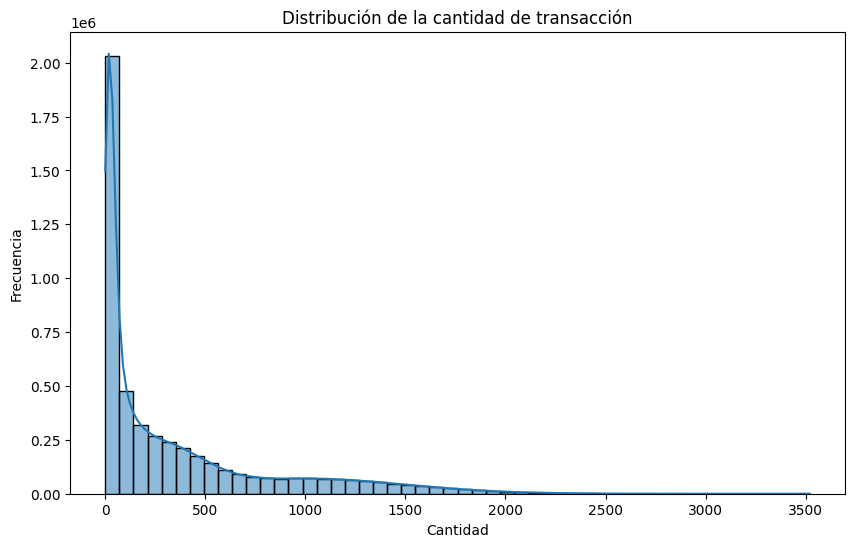

In [ ]:
# Histograma de la columna 'amount'
plt.figure(figsize=(10, 6))
sns.histplot(bdatosf['amount'], bins=50, kde=True)
plt.title('Distribución de la cantidad de transacción')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.show()

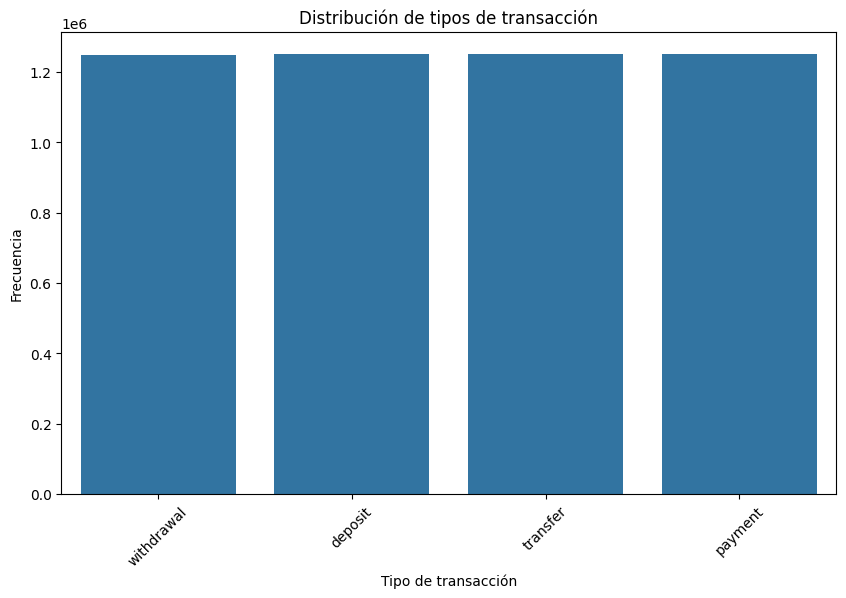

In [ ]:
# Gráfico de barras de la columna 'transaction_type'
plt.figure(figsize=(10, 6))
sns.countplot(data=bdatosf, x='transaction_type')
plt.title('Distribución de tipos de transacción')
plt.xlabel('Tipo de transacción')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

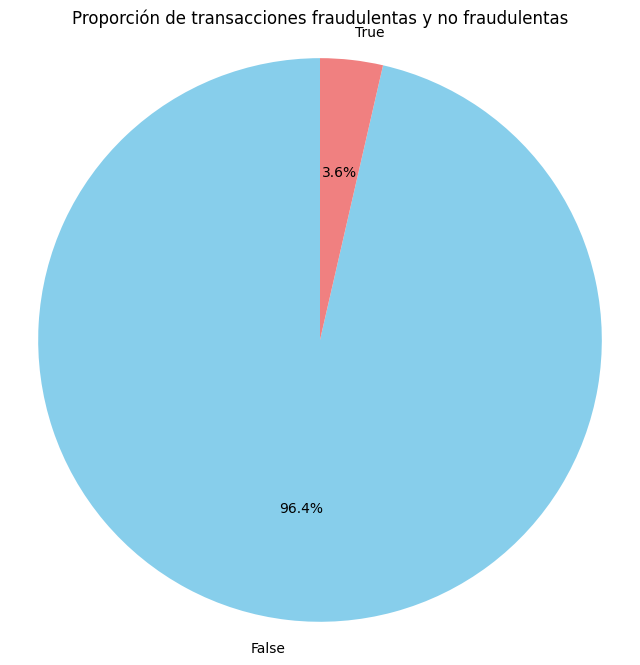

In [ ]:
# Contar la cantidad de cada valor en la columna 'is_fraud'
fraud_counts = bdatosf['is_fraud'].value_counts()

# Crear el gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(fraud_counts, labels=fraud_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Proporción de transacciones fraudulentas y no fraudulentas')
plt.axis('equal')  # Esto asegura que el gráfico de pastel sea un círculo.
plt.show()

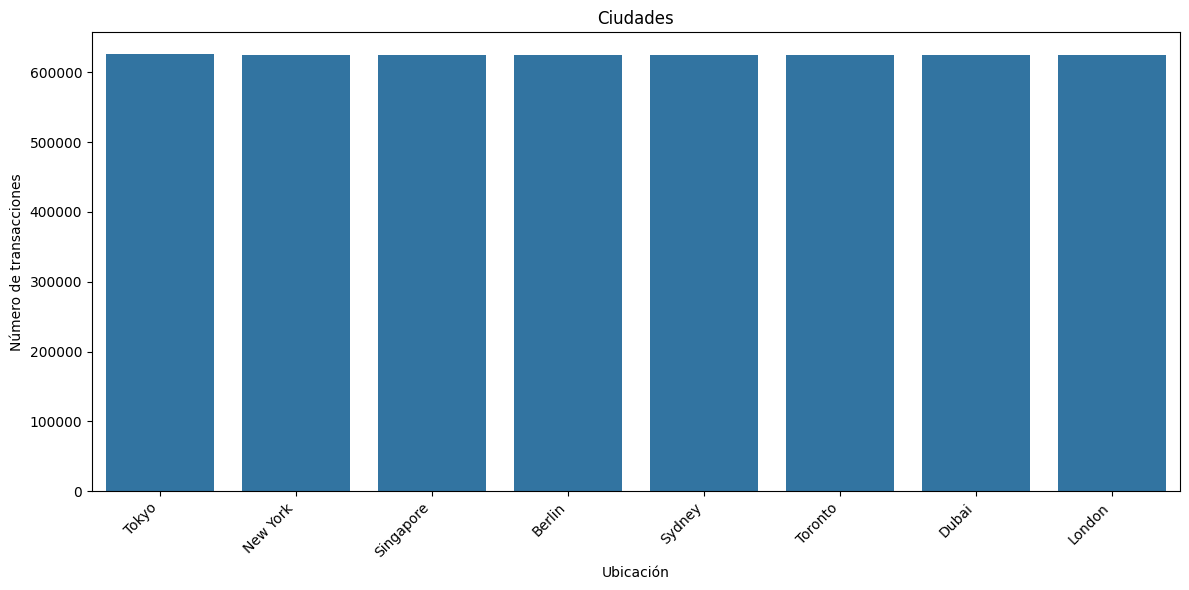

In [ ]:
# Contar la cantidad de transacciones por ubicación en bdatosf (Top 10)
top_locations_f = bdatosf['location'].value_counts().nlargest(10)

# Crear el gráfico de barras de las ubicaciones más frecuentes en bdatosf
plt.figure(figsize=(12, 6))
sns.barplot(x=top_locations_f.index, y=top_locations_f.values)
plt.title('Ciudades')
plt.xlabel('Ubicación')
plt.ylabel('Número de transacciones')
plt.xticks(rotation=45, ha='right') # Rota las etiquetas del eje x para mejor legibilidad
plt.tight_layout() # Ajusta el layout para evitar que las etiquetas se superpongan
plt.show()

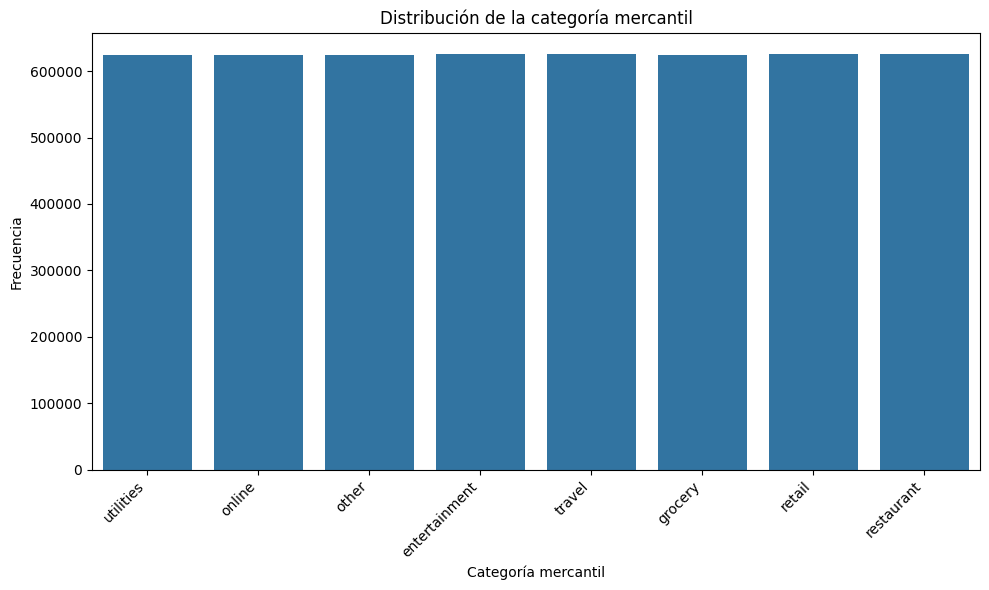

In [ ]:
# Histograma para 'merchant_category'
plt.figure(figsize=(10, 6))
sns.countplot(data=bdatosf, x='merchant_category')
plt.title('Distribución de la categoría mercantil')
plt.xlabel('Categoría mercantil')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

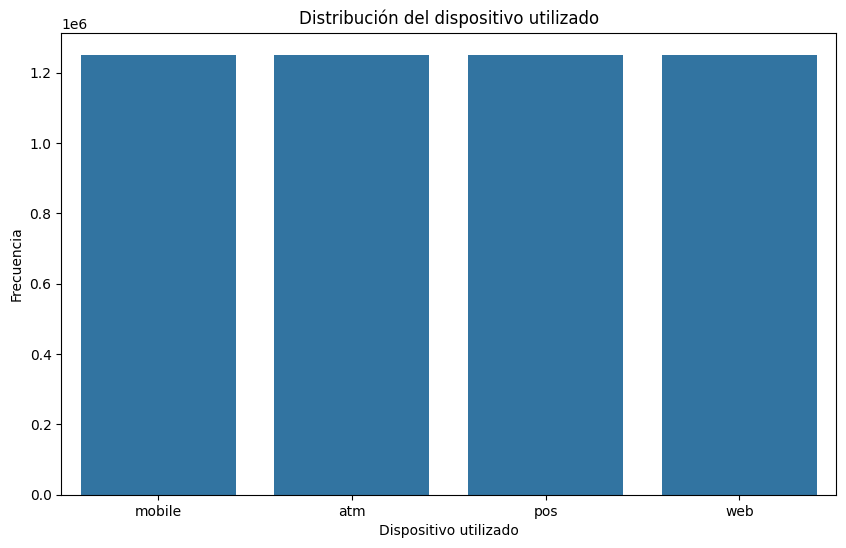

In [ ]:
# Histograma para 'device_used'
plt.figure(figsize=(10, 6))
sns.countplot(data=bdatosf, x='device_used')
plt.title('Distribución del dispositivo utilizado')
plt.xlabel('Dispositivo utilizado')
plt.ylabel('Frecuencia')
plt.show()

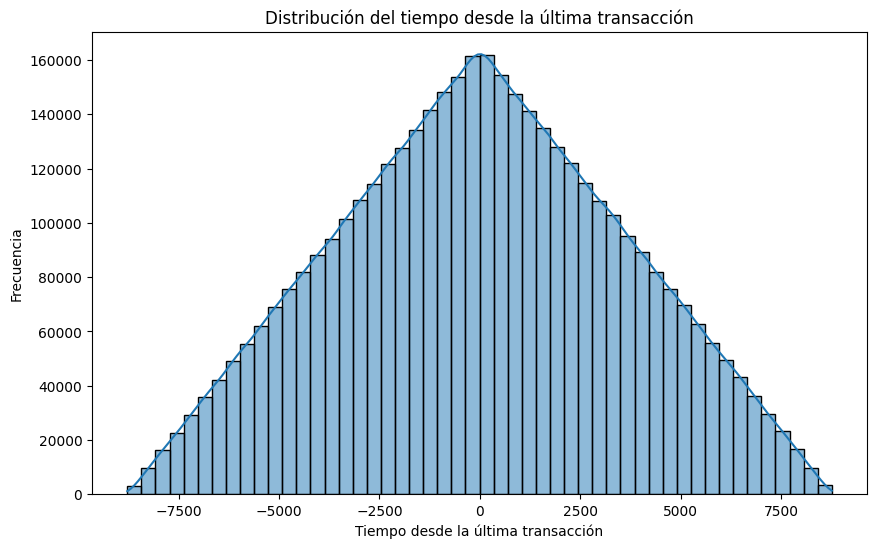

In [ ]:
# Histograma para 'time_since_last_transaction'
plt.figure(figsize=(10, 6))
sns.histplot(data=bdatosf, x='time_since_last_transaction', bins=50, kde=True)
plt.title('Distribución del tiempo desde la última transacción')
plt.xlabel('Tiempo desde la última transacción')
plt.ylabel('Frecuencia')
plt.show()

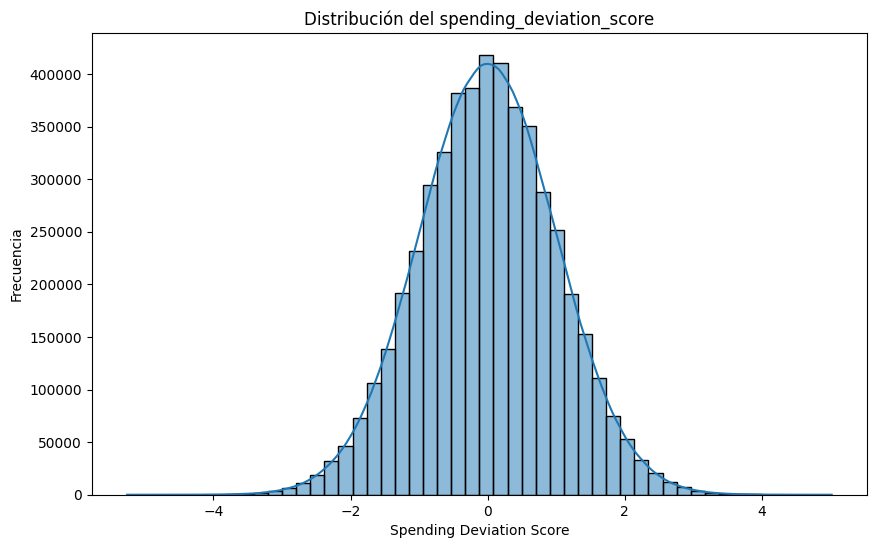

In [ ]:
# Histograma para 'spending_deviation_score'
plt.figure(figsize=(10, 6))
sns.histplot(data=bdatosf, x='spending_deviation_score', bins=50, kde=True)
plt.title('Distribución del spending_deviation_score')
plt.xlabel('Spending Deviation Score')
plt.ylabel('Frecuencia')
plt.show()

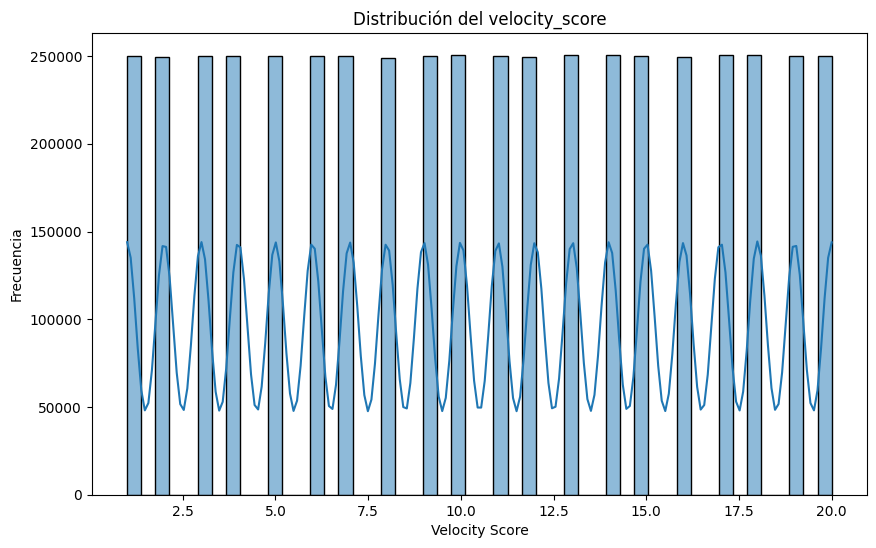

In [ ]:
# Histograma para 'velocity_score'
plt.figure(figsize=(10, 6))
sns.histplot(data=bdatosf, x='velocity_score', bins=50, kde=True)
plt.title('Distribución del velocity_score')
plt.xlabel('Velocity Score')
plt.ylabel('Frecuencia')
plt.show()

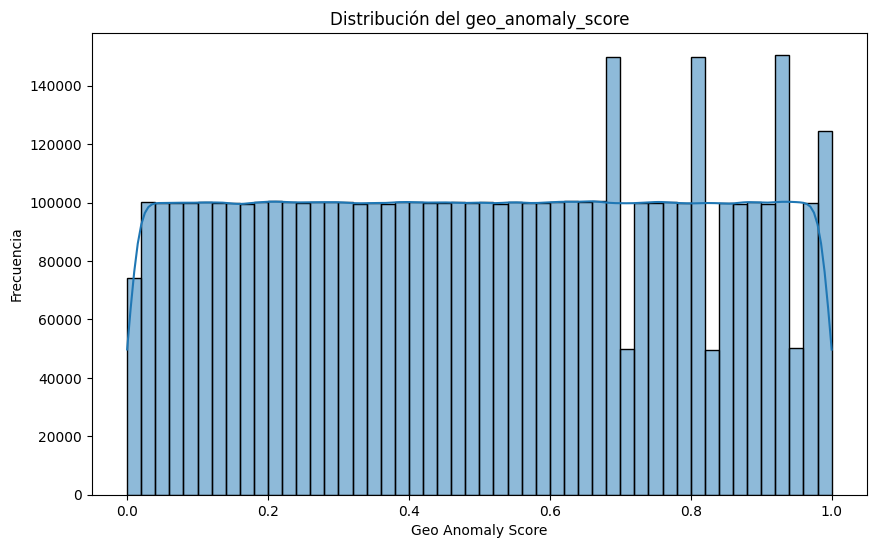

In [ ]:
# Histograma para 'geo_anomaly_score'
plt.figure(figsize=(10, 6))
sns.histplot(data=bdatosf, x='geo_anomaly_score', bins=50, kde=True)
plt.title('Distribución del geo_anomaly_score')
plt.xlabel('Geo Anomaly Score')
plt.ylabel('Frecuencia')
plt.show()

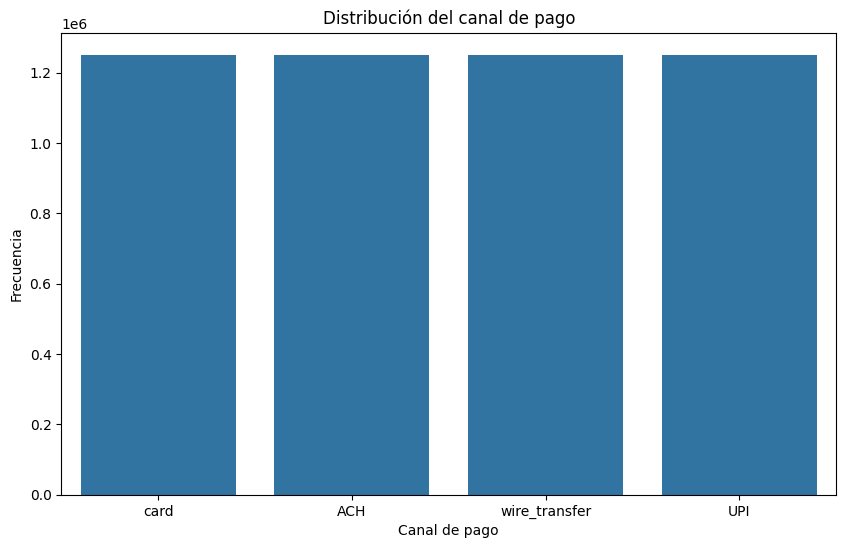

In [ ]:
# Histograma para 'payment_channel'
plt.figure(figsize=(10, 6))
sns.countplot(data=bdatosf, x='payment_channel')
plt.title('Distribución del canal de pago')
plt.xlabel('Canal de pago')
plt.ylabel('Frecuencia')
plt.show()

**Análisis y conclusiones**

En primer lugar se puede observar como la base de datos no es tan realista como se esperaba en un principio, por ejemplo la presencia de solo 8 ciudades, o la distribución equitativa de datos entre muchas de las variables como en canal de pago, donde tanto targeta de crédito como ACH, tranferencia por cable y UPI cuentan con exactamente la misma cantidad de datos cada uno, ligeramente por encima de los 1.2 millones.

En segundo lugar, se encuentran desafíos de procesamiento en las redes neuronales, que se demoran entre 30 minutos a una hora en procesarse cada una con los recursos gratiuitos de Google Colab, y esto tan solo al pronosticar los datos de entrada sin sesgo que son solo alrededor de 359000, por lo tanto se encuentra una imposibilidad de aplicar este modelo a la totalidad de datos de entrada disponibles (5 millones) como se deseaba, los cuales se pudieron procesar en unos pocos segundos en el caso del modelo Bayes.

Otros desafíos que llevaron a que no se ejecute según lo visto en el curso es
que la presencia de valores negativos como la desviación del consumo estándar, llevan a que la normalización utilizada hasta ahora no funcione correctamente, por lo que se tuvo que realizar normalización min-max recomendada por el texto guía, y por otro lado, ya que el modelo neuronal no entregaba valores de salida binomiales (0 o 1), se tuvo que aplicar un umbral de decisión, en el que un valor mayor a 0.5 se considera fraude (1) y un valor igual o menor a 0.5 se considera no fraude (0).

Sobre las correlaciones de la base de datos del modelo autoenconder, se consideran altamente fieles a la realidad dado a la poca pérdida alcanzada por este modelo al momento de su ultima iteración de alrededor de 9%, esta encuenta cómo velocity score es la variable mas influyente en el fraude con un valor de 0.004, seguida por población con -0.003, y como esta última sumada con canal de pago y tipo de transacción son las únicas con correlación negativa.

Con esta información anterior, se puede notar que MADALINE no fué capaz de materializar los pesos debidos para este, dado a que los tres pesos negativos que encuentra deberían ser positivos, y los pesos que deberían ser negativos, los encuentra como positivos, además el peso mas influyente de MADALINE es el tiempo desde la última transacción con -0.6, variable que según autoencoder debería ser la tercera con mas peso, y además tener impacto positivo.

Frente al desempeño de MADALINE también se puede notar que logró una correlación de 0.06 frente a sus datos de entrada, un valor muy decepcionante, y al revisar sus métricas derivadas de la matríz de confusión con respecto a sus datos de entrenamiento, se encuentran métricas de alrededor de 50% para la mayoría de las métricas, lo que no presenta una capacidad de predicción relevante, reflejando así algo similar a una predicción aleatoria a pesar de haber consumido cientos de miles de datos y decenas de iteraciones alrededor de múltiples neuronas.

Por otro lado, el desempeño de bayes frente a sus datos de entrada de entrenamiento representa mas desigualdad en sus métricas, mientras su mayoría de métricas siguen siendo cercanas al 50%, este en cambio logra una sensibilidad de 37% y especificidad del 70%, lo que significa que es muy malo detectando cuando hay verdaderos fraudes, pero decente encontrando verdaderos negativos o encontrando que transacciones no son fraudulentas.

Al evaluar al modelo frente a la totalidad de la base de datos (5 millones), se encuentran valores identicos exepto por predicción de negativos, el cual cambia a 97%, lo que representaría un muy buen desempeño en la detección de cuando no hay fraude, sin embargo dado a que este porcentaje es igual al sesgo de la base de datos total de no fraude / fraude, no se considera que sea una métrica que refleje un buen desempeño del modelo.

**Conclusión**
No se logró crear ningún modelo capaz de predecir con cierta precisión la presencia de fraude financiero en la base de datos presente, esto puede haber sido gracias a la complejidad de los datos, o a una base de datos deficiente, o error humano en el desarrollo del caso.

enlace video: https://youtu.be/TvyBB6h0mvE
